# Human Activity Recognition in Older Adults Using Wearable Accelerometer Data
**Jialu Wei | DATAX504 Deep Learning | Individual project**

I compare a small 1D CNN using lower-back and thigh signals with versions using
each sensor separately. Four classes are included: lying, sitting, standing,
and walking. Evaluation separates participants and checks continuous time windows.

## Run this notebook
1. Install the packages in `requirements.txt` in a Python environment.
2. Put `har70plus.zip` in the `data` folder, or place your original HAR70 ZIP
   beside this notebook. The submitted ZIP package includes the original data.
3. Run the cells from top to bottom. The full experiment trains 12 small models.
4. New results are written to `results_reproduced`; the submitted original results
   remain in `results` so a new run does not silently overwrite report evidence.

The code also exists as `train.py`, generated from these same code cells.
AI assistance was used for planning, code generation and correction, experiment
execution, figures and report drafting. I need to understand the code and check
the report before submitting it as my course project.

In [1]:
# Keep CPU use modest and request deterministic TensorFlow operations.
# These environment settings must be applied before importing TensorFlow.
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "2")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "1")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

from pathlib import Path
import json
import hashlib
import time
import platform
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold
import sklearn

keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

SEEDS = [42, 123, 2026]
MAX_EPOCHS = 30
PATIENCE = 5
BATCH_SIZE = 64
RUN_GROUPED_CV = True
OUTPUT_DIR = Path(os.environ.get("HAR70_OUTPUT_DIR", "results_reproduced"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(exist_ok=True)
(OUTPUT_DIR / "models").mkdir(exist_ok=True)

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__, "Keras:", keras.__version__)
print("numpy:", np.__version__, "pandas:", pd.__version__, "scikit-learn:", sklearn.__version__)
print("Seeds:", SEEDS, "maximum epochs:", MAX_EPOCHS, "patience:", PATIENCE)
print("Outputs:", OUTPUT_DIR)

Python: 3.12.14
TensorFlow: 2.20.0 Keras: 3.15.1
numpy: 2.3.5 pandas: 2.2.3 scikit-learn: 1.8.0
Seeds: [42, 123, 2026] maximum epochs: 30 patience: 5
Outputs: results


## 1. Original data and continuous-window preparation
The public HAR70+ data are described at https://archive.ics.uci.edu/dataset/780/har70
(Logacjov & Ustad, 2023; Ustad et al., 2023). The original data contain 18 participants,
six sensor channels and seven activity codes. I exclude shuffling and stairs,
which narrows the task. This differs from merging these activities into broader classes.

Keep all labels until continuous activity segments are identified. This prevents
excluded records or time gaps from joining separate walking bouts into one window.

In [2]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import platform

SEED = 42
np.random.seed(SEED)

DATA_SOURCE = None  # Example: Path("har70plus") or Path("har70plus.zip")
if DATA_SOURCE is None:
    candidates = [
        Path("har70(1).zip"), Path("har70.zip"), Path("har70plus.zip"),
        Path("data/har70plus.zip"), Path("data/har70plus"), Path("upload/har70(1).zip"), Path("../data/har70plus"), Path("har70plus")
    ]
    DATA_SOURCE = next((p for p in candidates if p.exists()), None)
if DATA_SOURCE is None:
    raise FileNotFoundError("Put the HAR70+ ZIP beside this notebook or set DATA_SOURCE.")
DATA_SOURCE = Path(DATA_SOURCE)

SENSOR_COLUMNS = ["back_x", "back_y", "back_z", "thigh_x", "thigh_y", "thigh_z"]
LABEL_NAMES = {1: "walking", 6: "standing", 7: "sitting", 8: "lying"}
CLASS_NAMES = ["lying", "sitting", "standing", "walking"]
NAME_TO_INDEX = {name: i for i, name in enumerate(CLASS_NAMES)}
WINDOW_SIZE = 100   # nominal 2 seconds at 50 Hz
STEP_SIZE = 50      # 50% overlap within a continuous activity bout
MAX_INTERVAL_SECONDS = 0.030  # allow millisecond timestamp rounding; split larger gaps

print("Python:", platform.python_version())
print("numpy:", np.__version__, "pandas:", pd.__version__)
print("Source:", DATA_SOURCE.name)

Python: 3.12.14
numpy: 2.3.5 pandas: 2.2.3
Source: har70plus.zip


In [3]:
frames = []
if DATA_SOURCE.is_file():
    with zipfile.ZipFile(DATA_SOURCE) as archive:
        names = sorted(n for n in archive.namelist() if n.endswith(".csv"))
        for name in names:
            with archive.open(name) as handle:
                frame = pd.read_csv(handle)
            frame["subject"] = Path(name).stem
            frames.append(frame)
else:
    for path in sorted(DATA_SOURCE.glob("*.csv")):
        frame = pd.read_csv(path)
        frame["subject"] = path.stem
        frames.append(frame)

if not frames:
    raise ValueError("No participant CSV files found.")
df_all = pd.concat(frames, ignore_index=True)
del frames
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="raise")
df_all = df_all.sort_values(["subject", "timestamp"]).reset_index(drop=True)

required = SENSOR_COLUMNS + ["timestamp", "label", "subject"]
assert not df_all[required].isna().any().any(), "Missing values need explicit handling."
assert np.isfinite(df_all[SENSOR_COLUMNS].to_numpy()).all()
assert df_all["subject"].nunique() == 18
assert len(df_all) == 2259597
assert set(df_all["label"].unique()) == {1, 3, 4, 5, 6, 7, 8}

interval = df_all.groupby("subject", sort=False)["timestamp"].diff().dt.total_seconds()
assert not (interval.dropna() <= 0).any(), "Duplicate or non-increasing timestamps."
print("Participants:", df_all["subject"].nunique())
print("Original rows:", len(df_all))
print("Original label counts:")
print(df_all["label"].value_counts().sort_index().to_string())
print("Median within-person interval (seconds):", interval.median())
print("Original recording gaps >30 ms:", int((interval > MAX_INTERVAL_SECONDS).sum()))

df_target = df_all[df_all["label"].isin(LABEL_NAMES)].copy()
df_target["activity"] = df_target["label"].map(LABEL_NAMES)
print("Rows in four target classes:", len(df_target))
print(df_target["activity"].value_counts().to_string())

Participants: 18
Original rows: 2259597
Original label counts:
label
1    1079312
3      66058
4       4560
5       4978
6     418055
7     483452
8     203182
Median within-person interval (seconds): 0.02
Original recording gaps >30 ms: 255
Rows in four target classes: 2184001
activity
walking     1079312
sitting      483452
standing     418055
lying        203182


## 2. Participant separation and window checks
The original split is retained: 14 train participants, validation 510/514, test
511/512. Earlier exploratory test outputs were viewed before this correction.
Therefore this is a held-out-participant course experiment, not a blind external
validation. No architecture or training setting is chosen from the corrected test scores.

Each window is created within one participant, one class and one uninterrupted
segment. A gap greater than 30 ms starts a new segment; observed within-window
intervals in the supplied data are 19–21 ms. Windows of 100 samples have 99 intervals,
so first-to-last timestamps span about 1.98 seconds (nominal duration: 2 seconds).

In [4]:
all_subjects = sorted(df_all["subject"].unique())
val_subjects = ["510", "514"]
test_subjects = ["511", "512"]
train_subjects = [s for s in all_subjects if s not in val_subjects + test_subjects]

assert len(train_subjects) == 14
assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)
assert set(train_subjects + val_subjects + test_subjects) == set(all_subjects)

for split_name, subjects in [("train", train_subjects), ("validation", val_subjects),
                              ("test", test_subjects)]:
    print(split_name, subjects)

class_by_person = pd.crosstab(df_target["subject"], df_target["activity"])
print("Participants missing at least one target class:")
print(class_by_person.loc[(class_by_person == 0).any(axis=1)].to_string())

train ['501', '502', '503', '504', '505', '506', '507', '508', '509', '513', '515', '516', '517', '518']
validation ['510', '514']
test ['511', '512']
Participants missing at least one target class:
activity  lying  sitting  standing  walking
subject                                    
518           0    54344     21443    62079


In [5]:
def create_continuous_windows(data, subjects, window_size=100, step_size=50):
    windows, labels, records = [], [], []
    for subject in subjects:
        person = data.loc[data["subject"] == subject].sort_values("timestamp").reset_index(drop=True)
        times = person["timestamp"].to_numpy(dtype="datetime64[ns]")
        original_labels = person["label"].to_numpy()
        sensors = person[SENSOR_COLUMNS].to_numpy(dtype=np.float32)
        gaps = np.diff(times).astype("timedelta64[ns]").astype(np.int64) / 1e9
        boundaries = np.flatnonzero(
            (original_labels[1:] != original_labels[:-1]) |
            (gaps > MAX_INTERVAL_SECONDS) | (gaps <= 0)
        ) + 1
        edges = np.r_[0, boundaries, len(person)]

        for segment_id, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
            label = int(original_labels[left])
            if label not in LABEL_NAMES:
                continue
            for start in range(left, right - window_size + 1, step_size):
                stop = start + window_size
                window_gaps = gaps[start:stop - 1]
                assert np.all(window_gaps > 0)
                assert np.all(window_gaps <= MAX_INTERVAL_SECONDS)
                assert np.all(original_labels[start:stop] == label)
                windows.append(sensors[start:stop])
                labels.append(NAME_TO_INDEX[LABEL_NAMES[label]])
                records.append({
                    "subject": subject, "segment": segment_id,
                    "activity": LABEL_NAMES[label],
                    "start_time": person.loc[start, "timestamp"],
                    "end_time": person.loc[stop - 1, "timestamp"],
                    "max_interval_seconds": float(window_gaps.max())
                })

    if not windows:
        raise ValueError("No complete continuous windows were generated.")
    return np.stack(windows), np.asarray(labels, dtype=np.int64), pd.DataFrame(records)

X_train_raw, y_train, meta_train = create_continuous_windows(df_all, train_subjects)
X_val_raw, y_val, meta_val = create_continuous_windows(df_all, val_subjects)
X_test_raw, y_test, meta_test = create_continuous_windows(df_all, test_subjects)

for name, X, y, meta in [
    ("train", X_train_raw, y_train, meta_train),
    ("validation", X_val_raw, y_val, meta_val),
    ("test", X_test_raw, y_test, meta_test)
]:
    assert X.shape == (len(y), WINDOW_SIZE, len(SENSOR_COLUMNS))
    assert len(meta) == len(y)
    assert set(np.unique(y)) == set(range(4))
    print(name, "shape:", X.shape)
    print("class counts:", dict(zip(CLASS_NAMES, np.bincount(y, minlength=4))))
    print("max interval (seconds):", meta["max_interval_seconds"].max())
    print("first-to-last span range (seconds):",
          ((meta["end_time"] - meta["start_time"]).dt.total_seconds().min(),
           (meta["end_time"] - meta["start_time"]).dt.total_seconds().max()))

train shape: (32203, 100, 6)
class counts: {'lying': np.int64(3189), 'sitting': np.int64(7624), 'standing': np.int64(5114), 'walking': np.int64(16276)}
max interval (seconds): 0.021
first-to-last span range (seconds): (np.float64(1.979), np.float64(1.981))
validation shape: (3991, 100, 6)
class counts: {'lying': np.int64(408), 'sitting': np.int64(976), 'standing': np.int64(625), 'walking': np.int64(1982)}
max interval (seconds): 0.021
first-to-last span range (seconds): (np.float64(1.979), np.float64(1.981))
test shape: (4172, 100, 6)
class counts: {'lying': np.int64(436), 'sitting': np.int64(958), 'standing': np.int64(696), 'walking': np.int64(2082)}
max interval (seconds): 0.021
first-to-last span range (seconds): (np.float64(1.979), np.float64(1.981))


## 3. Training-only normalisation and data audit
Standardisation uses training windows only. Single-sensor models use channel
subsets of exactly the same windows. The input contains no ID, timestamp or label.

In [6]:
train_mean = X_train_raw.mean(axis=(0, 1), dtype=np.float64).astype(np.float32)
train_std = X_train_raw.std(axis=(0, 1), dtype=np.float64).astype(np.float32)
assert (train_std > 0).all()

X_train = ((X_train_raw - train_mean) / train_std).astype(np.float32)
X_val = ((X_val_raw - train_mean) / train_std).astype(np.float32)
X_test = ((X_test_raw - train_mean) / train_std).astype(np.float32)

for X in [X_train, X_val, X_test]:
    assert np.isfinite(X).all()
print("Training channel mean after standardisation:")
print(X_train.mean(axis=(0, 1), dtype=np.float64).round(6))
print("Training channel std after standardisation:")
print(X_train.std(axis=(0, 1), dtype=np.float64).round(6))

BACK_CHANNELS = [0, 1, 2]
THIGH_CHANNELS = [3, 4, 5]
print("Both sensors:", X_train.shape)
print("Lower-back-only input:", X_train[:, :, BACK_CHANNELS].shape)
print("Class encoding:", NAME_TO_INDEX)

Training channel mean after standardisation:
[-0.  0. -0.  0.  0. -0.]
Training channel std after standardisation:
[1. 1. 1. 1. 1. 1.]
Both sensors: (32203, 100, 6)
Lower-back-only input: (32203, 100, 3)
Class encoding: {'lying': 0, 'sitting': 1, 'standing': 2, 'walking': 3}


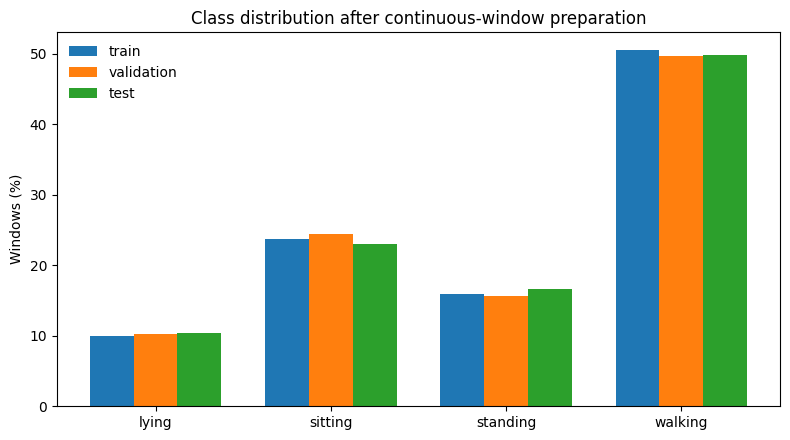

In [7]:
# Save data counts, participant lists and the supplied archive fingerprint.
split_counts = []
for split_name, y, meta in [("train", y_train, meta_train), ("validation", y_val, meta_val),
                          ("test", y_test, meta_test)]:
    counts = np.bincount(y, minlength=4)
    split_counts.append({"split": split_name, "participants": meta["subject"].nunique(),
                         "windows": len(y), **dict(zip(CLASS_NAMES, counts.tolist()))})
pd.DataFrame(split_counts).to_csv(OUTPUT_DIR / "window_counts.csv", index=False)
class_by_person.to_csv(OUTPUT_DIR / "raw_class_counts_by_participant.csv")
np.savez(OUTPUT_DIR / "normalisation.npz", mean=train_mean, std=train_std)

archive_sha256 = None
if DATA_SOURCE.is_file():
    archive_sha256 = hashlib.sha256(DATA_SOURCE.read_bytes()).hexdigest()
protocol = {
    "train_subjects": train_subjects, "validation_subjects": val_subjects,
    "test_subjects": test_subjects, "class_names": CLASS_NAMES,
    "sensor_columns": SENSOR_COLUMNS, "target_label_codes": list(LABEL_NAMES),
    "window_size": WINDOW_SIZE, "step_size": STEP_SIZE,
    "max_interval_seconds": MAX_INTERVAL_SECONDS, "seeds": SEEDS,
    "max_epochs": MAX_EPOCHS, "patience": PATIENCE, "batch_size": BATCH_SIZE,
    "learning_rate": 0.001, "archive_sha256": archive_sha256,
    "versions": {"python": platform.python_version(), "tensorflow": tf.__version__,
                 "keras": keras.__version__, "numpy": np.__version__,
                 "pandas": pd.__version__, "scikit_learn": sklearn.__version__},
    "previous_test_results_seen": True,
    "normalisation": "mean and std of training windows only",
    "representative_model_seed": 42,
    "representative_model_selection": "fixed seed, not best test score"
}
(OUTPUT_DIR / "protocol.json").write_text(json.dumps(protocol, indent=2))

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, row in enumerate(split_counts):
    counts = np.array([row[c] for c in CLASS_NAMES], dtype=float)
    ax.bar(np.arange(4) + (i - 1)*0.25, counts/counts.sum()*100, width=0.25,
           label=row["split"])
ax.set_xticks(range(4), CLASS_NAMES)
ax.set_ylabel("Windows (%)")
ax.set_title("Class distribution after continuous-window preparation")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures/class_distribution.png", dpi=200)
plt.show()
plt.close(fig)

## 4. Small 1D CNN and a controlled sensor ablation
Architecture: Conv1D(32,5) → MaxPool(2) → Conv1D(64,3) → GlobalAveragePool
→ Dense(32) → Dense(4, softmax). ReLU follows both convolutions and Dense(32).
The six-channel model has 9,412 parameters; either three-channel model has 8,932.
Only the input channels and naturally affected first-layer parameters change.

Adam uses learning rate 0.001. The loss is sparse categorical cross-entropy.
The model receives integer class labels. EarlyStopping monitors validation loss,
with patience 5, maximum 30 epochs and restoration of the best validation weights.
Accuracy is tracked during training; Macro F1 is the primary evaluation metric.
No class weighting is applied; class-level recall is checked to reveal imbalance effects.

For every input configuration, train all three preset seeds. Do not pick a run
because its test score is highest. Seed 42 is the preset representative for plots.

In [8]:
def build_model(n_channels):
    model = keras.Sequential([
        layers.Input(shape=(WINDOW_SIZE, n_channels)),
        layers.Conv1D(32, 5, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(4, activation="softmax")
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def make_dataset(X, y=None, training=False, seed=42):
    values = X if y is None else (X, y)
    dataset = tf.data.Dataset.from_tensor_slices(values)
    if training:
        dataset = dataset.shuffle(len(X), seed=seed, reshuffle_each_iteration=True)
    options = tf.data.Options()
    options.threading.private_threadpool_size = 1
    options.threading.max_intra_op_parallelism = 1
    options.experimental_deterministic = True
    return dataset.with_options(options).batch(BATCH_SIZE).prefetch(1)

def scores(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=np.arange(4),
                                   average="macro", zero_division=0))
    }

def fit_one(X_tr, y_tr, X_va, y_va, seed):
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)
    model = build_model(X_tr.shape[-1])
    callback = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                             restore_best_weights=True)
    started = time.perf_counter()
    history = model.fit(make_dataset(X_tr, y_tr, training=True, seed=seed),
                        validation_data=make_dataset(X_va, y_va),
                        epochs=MAX_EPOCHS, callbacks=[callback], verbose=0)
    seconds = time.perf_counter() - started
    probabilities = model.predict(make_dataset(X_va), verbose=0)
    details = {
        "epochs_trained": len(history.history["loss"]),
        "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
        "best_val_loss": float(min(history.history["val_loss"])),
        "parameters": int(model.count_params()), "training_seconds": float(seconds)
    }
    return model, history.history, scores(y_va, probabilities.argmax(axis=1)), details

print("Full model parameters:", build_model(6).count_params())
print("Single-sensor parameters:", build_model(3).count_params())

Full model parameters: 9412
Single-sensor parameters: 8932


## 5. Train all presets before inspecting corrected test results
All nine fits use the same prepared train and validation participants and labels.
Save models, learning histories and validation scores first. Test data are evaluated
only after this training phase finishes, with no follow-up model tuning.

In [9]:
INPUT_CONFIGS = {"both": [0, 1, 2, 3, 4, 5], "back_only": [0, 1, 2],
                 "thigh_only": [3, 4, 5]}
training_rows = []
for input_name, channels in INPUT_CONFIGS.items():
    for seed in SEEDS:
        print("Training", input_name, "seed", seed, flush=True)
        model, history, val_scores, details = fit_one(
            X_train[:, :, channels], y_train, X_val[:, :, channels], y_val, seed)
        run_name = f"{input_name}_seed{seed}"
        model.save(OUTPUT_DIR / "models" / f"{run_name}.keras")
        (OUTPUT_DIR / f"history_{run_name}.json").write_text(json.dumps(history, indent=2))
        training_rows.append({"input": input_name, "seed": seed,
                              "val_accuracy": val_scores["accuracy"],
                              "val_macro_f1": val_scores["macro_f1"], **details})
        print("Finished:", details, "validation:", val_scores, flush=True)
training_table = pd.DataFrame(training_rows)
training_table.to_csv(OUTPUT_DIR / "training_runs.csv", index=False)
print(training_table.to_string(index=False))

Training both seed 42
Finished: {'epochs_trained': 18, 'best_epoch': 13, 'best_val_loss': 0.013491295278072357, 'parameters': 9412, 'training_seconds': 37.532409414000085} validation: {'accuracy': 0.9982460536206464, 'macro_f1': 0.9983030271873297}
Training both seed 123
Finished: {'epochs_trained': 13, 'best_epoch': 8, 'best_val_loss': 0.026709208264946938, 'parameters': 9412, 'training_seconds': 28.46570150300022} validation: {'accuracy': 0.9939864695565022, 'macro_f1': 0.9937542923767388}
Training both seed 2026
Finished: {'epochs_trained': 6, 'best_epoch': 1, 'best_val_loss': 0.07125576585531235, 'parameters': 9412, 'training_seconds': 14.203833537000264} validation: {'accuracy': 0.9756953144575294, 'macro_f1': 0.9757024907735782}
Training back_only seed 42
Finished: {'epochs_trained': 6, 'best_epoch': 1, 'best_val_loss': 0.5301250219345093, 'parameters': 8932, 'training_seconds': 13.931332229000418} validation: {'accuracy': 0.7429215735404661, 'macro_f1': 0.6988206824168008}
Train

## 6. Grouped robustness check inside the original training participants
A 3-fold GroupKFold uses only the 14 original training participants. In each fold,
the held-out groups are untouched by fitting. The last two sorted participants of
the remaining groups form an inner early-stopping validation set. All normalisation
statistics are re-estimated from that fold's fitting participants only.

This evaluates only the full-input CNN with seed 42. It describes variation across
additional people; it does not select the best sensor model or tune the architecture.
The original validation/test participants are never included in this analysis.
Different folds also have different training sizes, so their scores are not a
direct substitute for the final 14/2/2 split.

In [10]:
cv_rows = []
if RUN_GROUPED_CV:
    groups = meta_train["subject"].to_numpy()
    group_kfold = GroupKFold(n_splits=3)
    for fold, (development_indices, heldout_indices) in enumerate(
            group_kfold.split(X_train_raw, y_train, groups), start=1):
        development_subjects = sorted(set(groups[development_indices]))
        inner_val_subjects = development_subjects[-2:]
        fit_subjects = development_subjects[:-2]
        fit_indices = np.flatnonzero(np.isin(groups, fit_subjects))
        inner_indices = np.flatnonzero(np.isin(groups, inner_val_subjects))
        heldout_subjects = sorted(set(groups[heldout_indices]))
        assert set(fit_subjects).isdisjoint(inner_val_subjects)
        assert set(fit_subjects + inner_val_subjects).isdisjoint(heldout_subjects)
        assert set(fit_subjects + inner_val_subjects + heldout_subjects).isdisjoint(
            val_subjects + test_subjects)

        fold_mean = X_train_raw[fit_indices].mean(axis=(0, 1), dtype=np.float64)
        fold_std = X_train_raw[fit_indices].std(axis=(0, 1), dtype=np.float64)
        assert (fold_std > 0).all()
        normalise = lambda X: ((X - fold_mean) / fold_std).astype(np.float32)
        print("Grouped fold", fold, "fit", fit_subjects, "inner validation", inner_val_subjects,
              "held out", heldout_subjects, flush=True)
        model, history, _, details = fit_one(
            normalise(X_train_raw[fit_indices]), y_train[fit_indices],
            normalise(X_train_raw[inner_indices]), y_train[inner_indices], seed=42)
        fold_probs = model.predict(make_dataset(normalise(X_train_raw[heldout_indices])), verbose=0)
        fold_predictions = fold_probs.argmax(axis=1)
        fold_scores = scores(y_train[heldout_indices], fold_predictions)
        cv_rows.append({"fold": fold, "fit_subjects": ",".join(fit_subjects),
                        "inner_validation_subjects": ",".join(inner_val_subjects),
                        "heldout_subjects": ",".join(heldout_subjects),
                        "heldout_windows": len(heldout_indices), **fold_scores, **details})
        pd.DataFrame({"subject": groups[heldout_indices],
                      "true": y_train[heldout_indices], "predicted": fold_predictions}).to_csv(
                      OUTPUT_DIR / f"grouped_fold{fold}_predictions.csv", index=False)
        (OUTPUT_DIR / f"history_grouped_fold{fold}.json").write_text(json.dumps(history, indent=2))
        print("Fold result:", fold_scores, flush=True)
    pd.DataFrame(cv_rows).to_csv(OUTPUT_DIR / "grouped_cv.csv", index=False)
    print(pd.DataFrame(cv_rows).to_string(index=False))
else:
    print("Grouped CV disabled: the reproduction will not include this report analysis.")

Grouped fold 1 fit ['501', '502', '503', '504', '506', '507', '516'] inner validation ['517', '518'] held out ['505', '508', '509', '513', '515']
Fold result: {'accuracy': 0.9477282950967162, 'macro_f1': 0.9320778021411364}
Grouped fold 2 fit ['503', '505', '508', '509', '513', '515', '516'] inner validation ['517', '518'] held out ['501', '502', '504', '506', '507']
Fold result: {'accuracy': 0.982946141129383, 'macro_f1': 0.9814060436973928}
Grouped fold 3 fit ['501', '502', '504', '505', '506', '507', '508', '509'] inner validation ['513', '515'] held out ['503', '516', '517', '518']
Fold result: {'accuracy': 0.9611255862428348, 'macro_f1': 0.9416503803732601}
 fold                    fit_subjects inner_validation_subjects    heldout_subjects  heldout_windows  accuracy  macro_f1  epochs_trained  best_epoch  best_val_loss  parameters  training_seconds
    1     501,502,503,504,506,507,516                   517,518 505,508,509,513,515            11115  0.947728  0.932078               

## 7. Held-out test metrics and participant-level error analysis
All preset runs are evaluated. Report means and sample standard deviations across
seeds, plus the preset seed-42 confusion matrix and class metrics. Seed variability
is not a confidence interval across older adults. A majority-walking reference
helps show why accuracy alone would be insufficient.

In [11]:
test_rows, subject_rows, class_rows = [], [], []
for input_name, channels in INPUT_CONFIGS.items():
    for seed in SEEDS:
        run_name = f"{input_name}_seed{seed}"
        model = keras.models.load_model(OUTPUT_DIR / "models" / f"{run_name}.keras")
        probabilities = model.predict(make_dataset(X_test[:, :, channels]), verbose=0)
        predictions = probabilities.argmax(axis=1)
        row = {"input": input_name, "seed": seed, **scores(y_test, predictions)}
        test_rows.append(row)
        print("Test:", row, flush=True)

        prediction_table = meta_test.copy()
        prediction_table["true"] = y_test
        prediction_table["predicted"] = predictions
        prediction_table["confidence"] = probabilities.max(axis=1)
        for i, name in enumerate(CLASS_NAMES):
            prediction_table[f"prob_{name}"] = probabilities[:, i]
        prediction_table.to_csv(OUTPUT_DIR / f"predictions_{run_name}.csv", index=False)
        for subject in test_subjects:
            mask = meta_test["subject"].eq(subject).to_numpy()
            subject_rows.append({"input": input_name, "seed": seed, "subject": subject,
                                 "windows": int(mask.sum()), **scores(y_test[mask], predictions[mask])})

        if seed == 42:
            report = classification_report(y_test, predictions, labels=range(4),
                                           target_names=CLASS_NAMES, output_dict=True,
                                           zero_division=0)
            (OUTPUT_DIR / f"classification_{input_name}_seed42.json").write_text(json.dumps(report, indent=2))
            for name in CLASS_NAMES:
                class_rows.append({"input": input_name, "class": name, **report[name]})
            cm = confusion_matrix(y_test, predictions, labels=range(4))
            np.savetxt(OUTPUT_DIR / f"confusion_{input_name}_seed42.csv", cm, delimiter=",", fmt="%d")

test_table = pd.DataFrame(test_rows)
subject_table = pd.DataFrame(subject_rows)
test_table.to_csv(OUTPUT_DIR / "test_runs.csv", index=False)
subject_table.to_csv(OUTPUT_DIR / "test_by_participant.csv", index=False)
pd.DataFrame(class_rows).to_csv(OUTPUT_DIR / "class_metrics_seed42.csv", index=False)

test_summary = test_table.groupby("input", sort=False).agg(
    accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"))
test_summary.to_csv(OUTPUT_DIR / "test_summary.csv")
print("Mean and sample SD across the three predetermined seeds:")
print(test_summary.to_string())

majority_class = int(np.bincount(y_train).argmax())
majority_scores = scores(y_test, np.full(len(y_test), majority_class))
(OUTPUT_DIR / "majority_reference.json").write_text(json.dumps(
    {"class": CLASS_NAMES[majority_class], **majority_scores}, indent=2))
print("Training-majority reference:", CLASS_NAMES[majority_class], majority_scores)

paired = test_table.pivot(index="seed", columns="input", values="macro_f1")
paired["both_minus_back"] = paired["both"] - paired["back_only"]
paired["both_minus_thigh"] = paired["both"] - paired["thigh_only"]
paired.to_csv(OUTPUT_DIR / "paired_seed_differences.csv")
print("Paired seed differences:")
print(paired.to_string())

Test: {'input': 'both', 'seed': 42, 'accuracy': 0.9990412272291467, 'macro_f1': 0.9990414554970354}
Test: {'input': 'both', 'seed': 123, 'accuracy': 0.9944870565675935, 'macro_f1': 0.9945427608433738}
Test: {'input': 'both', 'seed': 2026, 'accuracy': 0.9959252157238735, 'macro_f1': 0.9959242359776405}
Test: {'input': 'back_only', 'seed': 42, 'accuracy': 0.8696069031639502, 'macro_f1': 0.8362561033589424}
Test: {'input': 'back_only', 'seed': 123, 'accuracy': 0.862176414189837, 'macro_f1': 0.8279439477591427}
Test: {'input': 'back_only', 'seed': 2026, 'accuracy': 0.8652924256951102, 'macro_f1': 0.8341090627635104}
Test: {'input': 'thigh_only', 'seed': 42, 'accuracy': 0.8593000958772771, 'macro_f1': 0.7388178495956118}
Test: {'input': 'thigh_only', 'seed': 123, 'accuracy': 0.9506232023010547, 'macro_f1': 0.9160585597123534}
Test: {'input': 'thigh_only', 'seed': 2026, 'accuracy': 0.9594918504314478, 'macro_f1': 0.9313863729777009}
Mean and sample SD across the three predetermined seeds:
  

## 8. Figures and specific error examples
Show confusion-matrix counts and recall fractions for seed 42. Inspect the five
most confident incorrect windows per configuration. Confidence is a softmax score,
not calibrated clinical certainty. Several overlapping windows can come from the
same episode, so error windows are not independent clinical events.

Representative full-input participant scores:
input  seed subject  windows  accuracy  macro_f1
 both    42     511     2236  0.999106  0.998608
 both    42     512     1936  0.998967  0.999216
Full-input class metrics:
input    class  precision   recall  f1-score  support
 both    lying   1.000000 1.000000  1.000000    436.0
 both  sitting   1.000000 1.000000  1.000000    958.0
 both standing   0.997126 0.997126  0.997126    696.0
 both  walking   0.999039 0.999039  0.999039   2082.0
Experiments complete. Results and figures saved to results


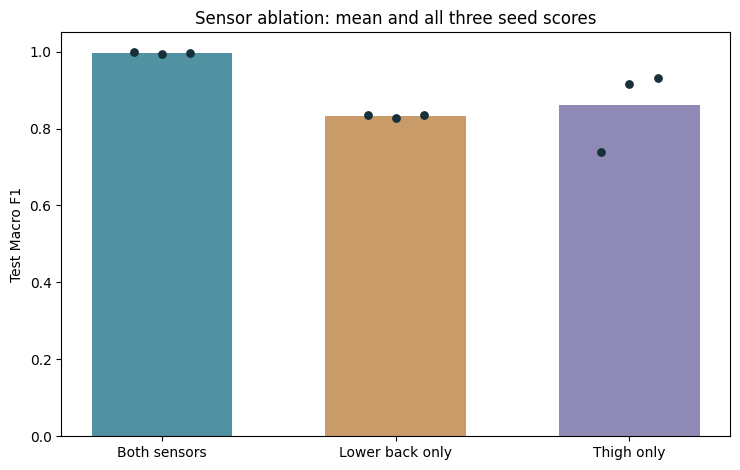

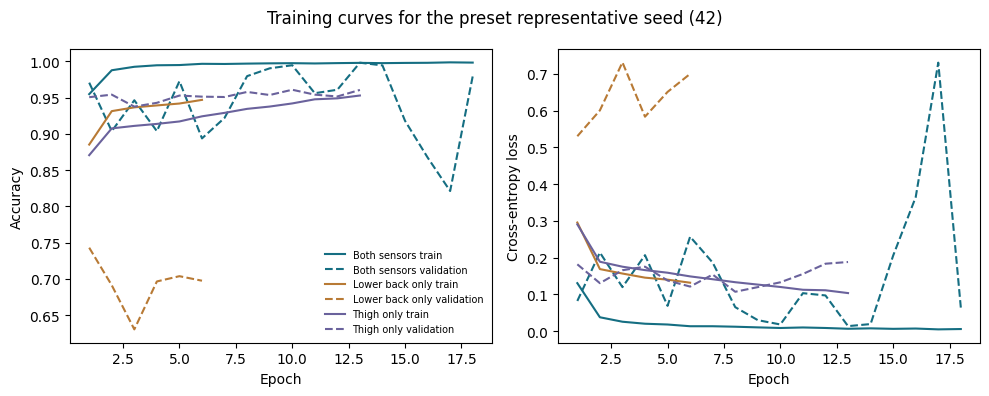

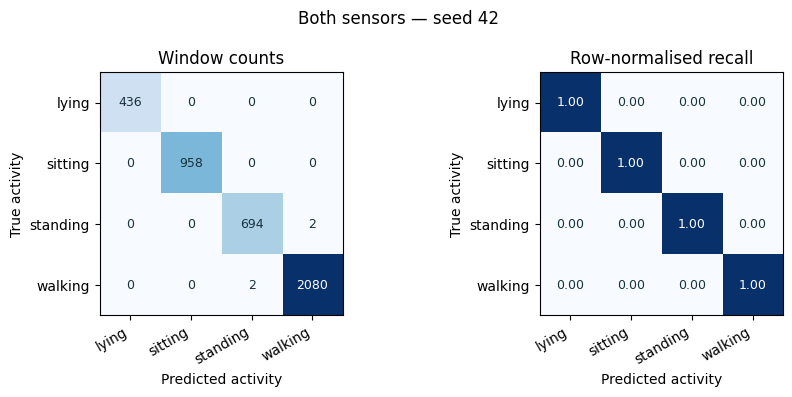

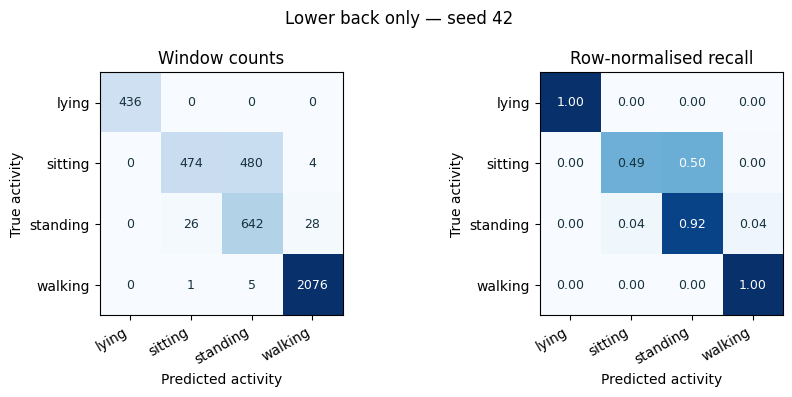

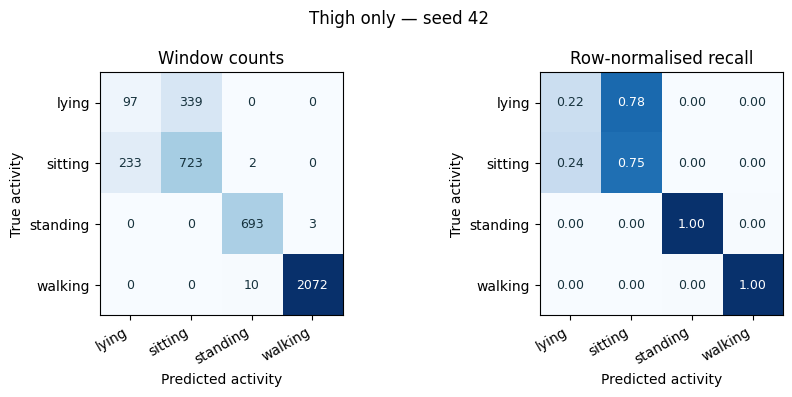

In [12]:
DISPLAY_NAMES = {"both": "Both sensors", "back_only": "Lower back only", "thigh_only": "Thigh only"}
colours = {"both": "#156E82", "back_only": "#B87A35", "thigh_only": "#6A629C"}

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for i, input_name in enumerate(INPUT_CONFIGS):
    sub = test_table[test_table["input"].eq(input_name)]
    ax.bar(i, sub["macro_f1"].mean(), color=colours[input_name], alpha=0.75, width=0.6)
    ax.scatter(i + np.linspace(-0.12, 0.12, len(sub)), sub["macro_f1"], color="#172F3A", s=28, zorder=3)
ax.set_xticks(range(3), [DISPLAY_NAMES[n] for n in INPUT_CONFIGS])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Macro F1")
ax.set_title("Sensor ablation: mean and all three seed scores")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures/sensor_comparison.png", dpi=220)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for input_name in INPUT_CONFIGS:
    history = json.loads((OUTPUT_DIR / f"history_{input_name}_seed42.json").read_text())
    epochs = np.arange(1, len(history["loss"]) + 1)
    axes[0].plot(epochs, history["accuracy"], color=colours[input_name],
                 label=DISPLAY_NAMES[input_name] + " train")
    axes[0].plot(epochs, history["val_accuracy"], linestyle="--", color=colours[input_name],
                 label=DISPLAY_NAMES[input_name] + " validation")
    axes[1].plot(epochs, history["loss"], color=colours[input_name])
    axes[1].plot(epochs, history["val_loss"], linestyle="--", color=colours[input_name])
axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Cross-entropy loss")
for ax in axes: ax.set_xlabel("Epoch")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Training curves for the preset representative seed (42)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures/training_curves.png", dpi=220)
plt.show()
plt.close(fig)

for input_name in INPUT_CONFIGS:
    cm = np.loadtxt(OUTPUT_DIR / f"confusion_{input_name}_seed42.csv", delimiter=",", dtype=int)
    recall = cm / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, values, title in [(axes[0], cm, "Window counts"), (axes[1], recall, "Row-normalised recall")]:
        ax.imshow(values, cmap="Blues", vmin=0, vmax=None if title == "Window counts" else 1)
        for r in range(4):
            for c in range(4):
                label = str(cm[r, c]) if title == "Window counts" else f"{recall[r,c]:.2f}"
                ax.text(c, r, label, ha="center", va="center", fontsize=9,
                        color="white" if values[r,c] > values.max()/2 else "#16323D")
        ax.set_xticks(range(4), CLASS_NAMES, rotation=30, ha="right")
        ax.set_yticks(range(4), CLASS_NAMES)
        ax.set_xlabel("Predicted activity")
        ax.set_ylabel("True activity")
        ax.set_title(title)
    fig.suptitle(DISPLAY_NAMES[input_name] + " — seed 42")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"figures/confusion_{input_name}_seed42.png", dpi=220)
    plt.show()
    plt.close(fig)

error_tables = []
for input_name in INPUT_CONFIGS:
    predictions = pd.read_csv(OUTPUT_DIR / f"predictions_{input_name}_seed42.csv")
    errors = predictions[predictions["true"] != predictions["predicted"]].copy()
    errors["true_activity"] = errors["true"].map(dict(enumerate(CLASS_NAMES)))
    errors["predicted_activity"] = errors["predicted"].map(dict(enumerate(CLASS_NAMES)))
    errors["input"] = input_name
    error_tables.append(errors.sort_values("confidence", ascending=False).head(5))
pd.concat(error_tables, ignore_index=True).to_csv(OUTPUT_DIR / "error_examples_seed42.csv", index=False)
print("Representative full-input participant scores:")
print(subject_table[subject_table["input"].eq("both") & subject_table["seed"].eq(42)].to_string(index=False))
print("Full-input class metrics:")
print(pd.DataFrame(class_rows).query("input == 'both'").to_string(index=False))
print("Experiments complete. Results and figures saved to", OUTPUT_DIR)

## 9. Interpretation and limitations
- Use the generated tables to answer the three research questions; do not copy the
  older notebook's accuracy. A sensor effect may depend on the seed and participant.
- Subject-level separation prevents the same person appearing in fitting and test
  sets, but only two final test participants give weak population-level evidence.
- Repeated seed scores describe optimisation variation, not population uncertainty.
- Excluding rare activities and transition windows simplifies the task. Performance
  here does not describe stairs, shuffling, transitions, falls or clinical outcomes.
- Many windows overlap. Do not use them as independent people in a significance test.
- Grouped CV uses fewer fitting people per fold and may expose unstable generalisation.
- The best weights are chosen by validation loss, which may differ from Macro F1.
- Source papers and documentation are verified; differences in protocols prevent a
  direct claim of beating the published HAR70+ model.
- The README describes setup and reproduction. The student must review the report,
  AI disclosure and code and prepare to explain the model in the presentation.